# Unsupervised Learning  (K-Mean-Clustering)

In [1]:
# ye accuracy nhi deta model ki... ye bss data ko clusters me divide kr deta haii

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("uber-raw-data-aug14.csv")

In [4]:
df.head()

,Date/Time,Lat,Lon,Base
0,8/1/2014 0:03:00,40.7366,-73.9906,B02512
1,8/1/2014 0:09:00,40.7260,-73.9918,B02512
2,8/1/2014 0:12:00,40.7209,-74.0507,B02512
3,8/1/2014 0:12:00,40.7387,-73.9856,B02512
4,8/1/2014 0:12:00,40.7323,-74.0077,B02512


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829275 entries, 0 to 829274
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  829275 non-null  object 
 1   Lat        829275 non-null  float64
 2   Lon        829275 non-null  float64
 3   Base       829275 non-null  object 
dtypes: float64(2), object(2)
memory usage: 25.3+ MB


In [6]:
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(15882)

In [8]:
df.drop_duplicates(df)

,Date/Time,Lat,Lon,Base
0,8/1/2014 0:03:00,40.7366,-73.9906,B02512
1,8/1/2014 0:09:00,40.7260,-73.9918,B02512
2,8/1/2014 0:12:00,40.7209,-74.0507,B02512
3,8/1/2014 0:12:00,40.7387,-73.9856,B02512
4,8/1/2014 0:12:00,40.7323,-74.0077,B02512
...,...,...,...,...
829269,8/31/2014 23:55:00,40.7267,-73.9998,B02764
829270,8/31/2014 23:55:00,40.7552,-73.9753,B02764
829272,8/31/2014 23:55:00,40.7617,-73.9788,B02764
829273,8/31/2014 23:59:00,40.7395,-73.9889,B02764


In [9]:
df["Date/Time"] = pd.to_datetime(df["Date/Time"])

In [10]:
df.head()

,Date/Time,Lat,Lon,Base
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512


In [11]:
df["Day"] = df["Date/Time"].dt.day

In [12]:
df.head()

,Date/Time,Lat,Lon,Base,Day
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,1
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,1
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,1
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,1
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,1


In [13]:
df["Hours"] = df["Date/Time"].dt.hour

In [14]:
df.head()

,Date/Time,Lat,Lon,Base,Day,Hours
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,1,0
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,1,0
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,1,0
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,1,0
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,1,0


In [15]:
df["Weekday"] = df["Date/Time"].dt.day_name()

In [16]:
df.head()

,Date/Time,Lat,Lon,Base,Day,Hours,Weekday
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,1,0,Friday
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,1,0,Friday
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,1,0,Friday
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,1,0,Friday
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,1,0,Friday


In [17]:
X = df[["Lat", "Lon"]]

In [18]:
X.head()

,Lat,Lon
0,40.7366,-73.9906
1,40.7260,-73.9918
2,40.7209,-74.0507
3,40.7387,-73.9856
4,40.7323,-74.0077


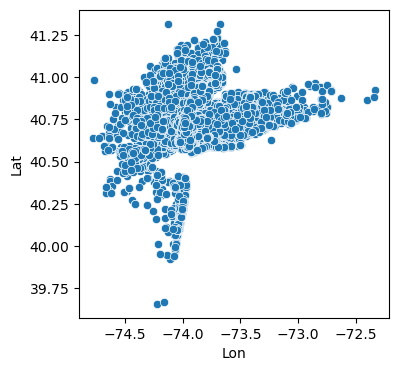

In [19]:
plt.figure(figsize=(4,4))
sns.scatterplot(x = df["Lon"], y = df["Lat"])
plt.show()

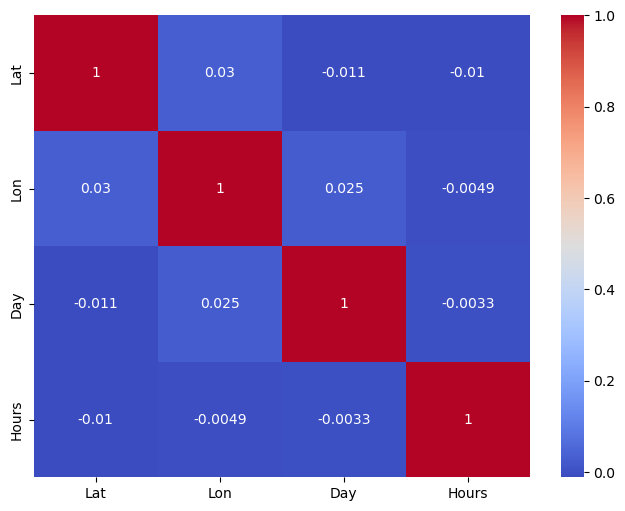

In [20]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

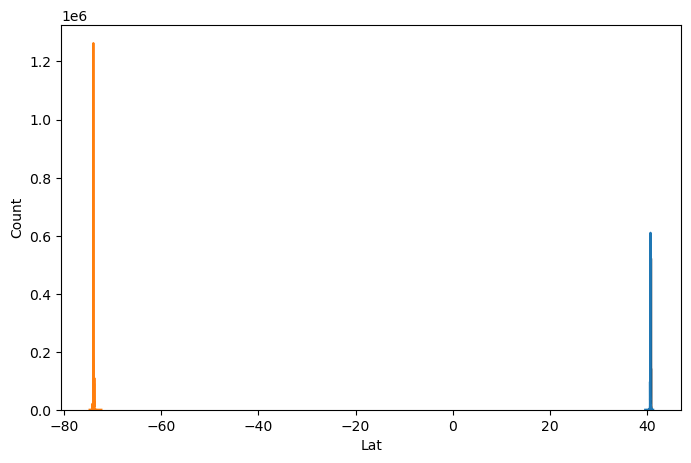

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["Lat"], bins=30,kde=True)
sns.histplot(df["Lon"], bins=30, kde=True)
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
X_scaled

array([[-0.0270637 , -0.3324462 ],
       [-0.27002674, -0.35196388],
       [-0.38692405, -1.30995708],
       ...,
       [ 0.54825445, -0.14052226],
       [ 0.03940733, -0.30479614],
       [-0.2471057 , -0.1632929 ]], shape=(829275, 2))

In [24]:
from sklearn.cluster import KMeans

In [25]:
c = []

In [26]:
for i in range (1,11):
    model = KMeans( n_clusters = i, random_state = 42, n_init = 10)
    model.fit(X_scaled)
    c.append(model.inertia_)

In [27]:
c

[1658549.9999999774,
 1186157.0146998807,
 849331.9295523881,
 699794.4007238767,
 599044.8596852632,
 507661.78050215857,
 428496.4081555415,
 360399.8726488482,
 301772.55651477224,
 262187.23434771714]

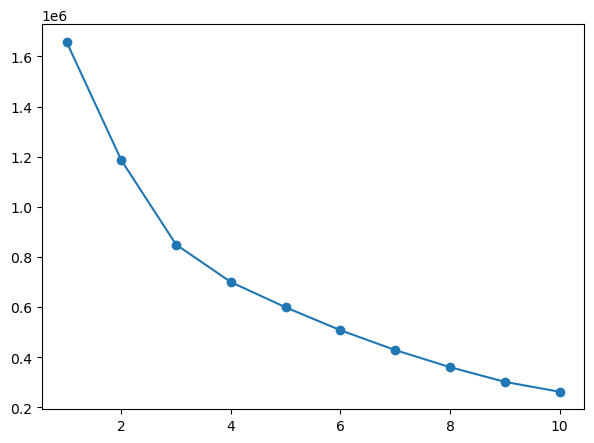

In [28]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11), c, marker = "o")
plt.show()

In [29]:
model = KMeans(n_clusters=5, random_state=42, n_init=10 )

In [30]:
cluster = model.fit_predict(X_scaled)

In [31]:
df["cluster"] = cluster

In [32]:
df.head()

,Date/Time,Lat,Lon,Base,Day,Hours,Weekday,cluster
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,1,0,Friday,1
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,1,0,Friday,4
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,1,0,Friday,4
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,1,0,Friday,1
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,1,0,Friday,1


In [33]:
df["cluster"].value_counts()

cluster
1    432372
4    293484
2     63069
0     31802
3      8548
Name: count, dtype: int64

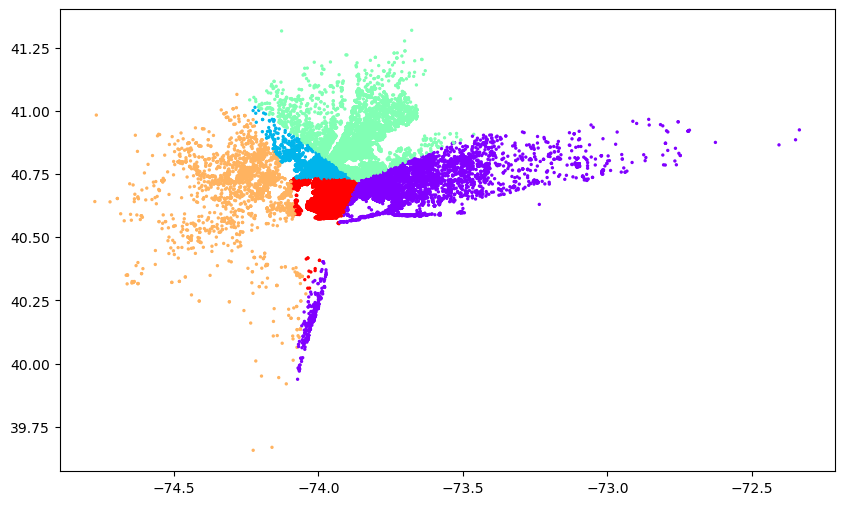

In [34]:
plt.figure(figsize=(10,6))
plt.scatter(df["Lon"], df["Lat"], c = df["cluster"], cmap = "rainbow", s=2)

In [35]:
centeroid = scaler.inverse_transform(model.cluster_centers_)

In [36]:
centeroid

array([[ 40.66278568, -73.76666899],
       [ 40.75530722, -73.98192107],
       [ 40.805137  , -73.89718765],
       [ 40.69423374, -74.20036889],
       [ 40.70669713, -73.98392295]])

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [43]:
train = model.predict(X_train)
test = model.predict(X_test)

C:\Users\cxash\anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
C:\Users\cxash\anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


In [44]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

In [45]:
dt.fit(X_train, train)
pred = dt.predict(X_test)

In [46]:
pred

array([3, 3, 3, ..., 3, 3, 3], shape=(165855,), dtype=int32)

In [47]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(test_labels, pred)
print("Accuracy:", acc*100)

Accuracy: 100.0
